# Deep Learning Project — Multi-Modal Classification (Flickr8k)

**Dataset** : Flickr8k — 8 000 images, 5 captions par image  
**Pipeline** :
- **Step 1** — Image Processing with CNN (ResNet50)
- **Step 2** — Text Processing with Embeddings and RNN
- **Step 3** — Multi-Modal Fusion
- **Step 4** — Model Tuning & Optimization

---
# Step 1 — Image Processing with CNN (ResNet50)

**Objectif** : Prétraiter les images Flickr8k et extraire des features visuelles avec ResNet50 pré-entraîné.

Pipeline :
1. Chargement et visualisation des données
2. Prétraitement des images (resize + normalisation)
3. Extraction de features avec ResNet50 (sans la couche finale)
4. Sauvegarde des features pour la fusion multi-modale (Step 3)

## 1. Imports et configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

# Chemins
DATA_DIR   = '../data/raw/'
IMG_DIR    = os.path.join(DATA_DIR, 'Images')
CAPTIONS   = os.path.join(DATA_DIR, 'captions.txt')
SAVE_DIR   = '../data/processed/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cpu


## 2. Chargement et exploration des données

In [2]:
# Chargement des captions
df = pd.read_csv(CAPTIONS)
print(df.shape)
df.head(10)

(40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [3]:
# Vérification des colonnes
print('Colonnes :', df.columns.tolist())
print('Nombre d\'images uniques :', df.iloc[:, 0].nunique())

# Renommage pour uniformité
df.columns = ['image', 'caption']
df.head()

Colonnes : ['image', 'caption']
Nombre d'images uniques : 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


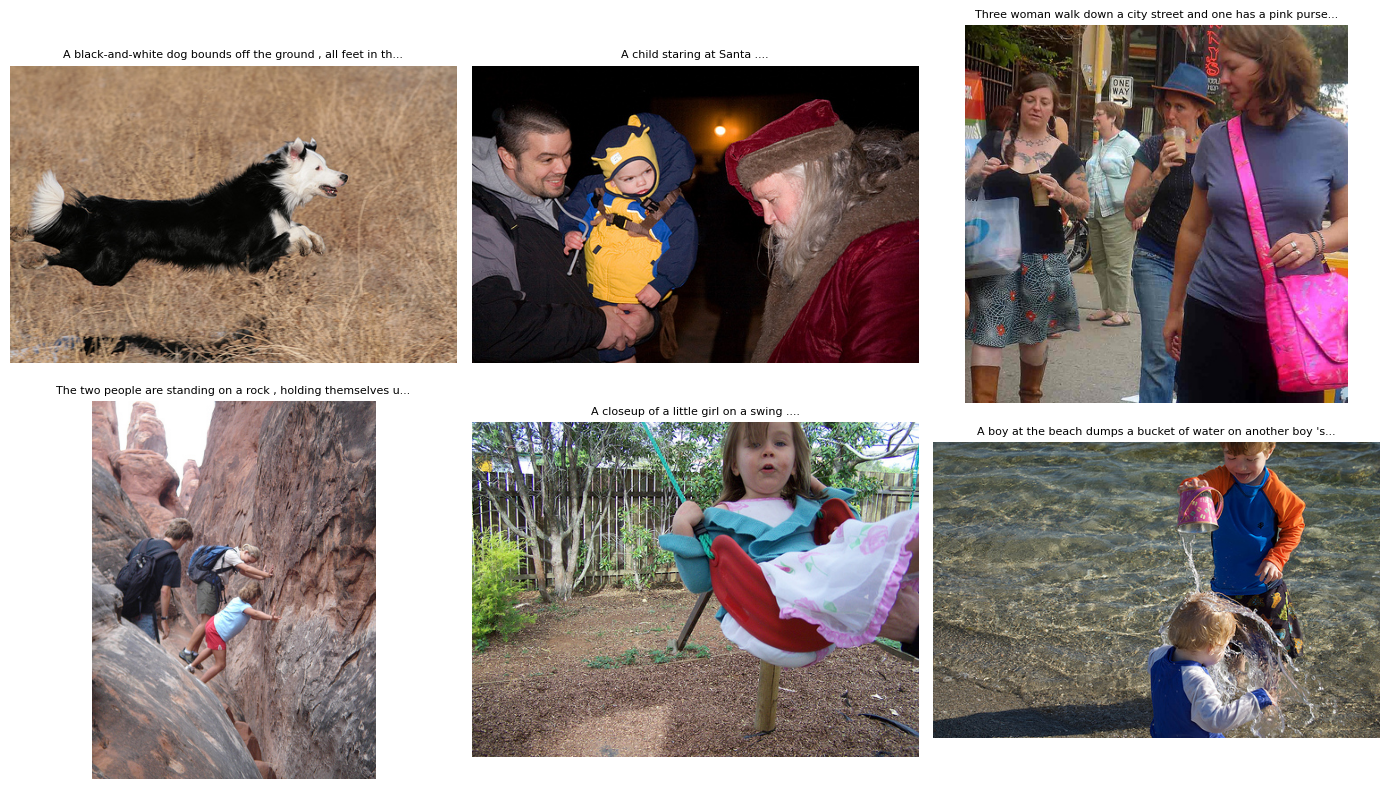

In [4]:
# Visualisation de quelques images avec leurs captions
sample = df.drop_duplicates('image').sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img_path = os.path.join(IMG_DIR, row['image'])
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(row['caption'][:60] + '...', fontsize=8, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=150)
plt.show()

## 3. Prétraitement des images

ResNet50 attend des images de taille **224×224**, normalisées avec la moyenne et l'écart-type d'ImageNet :
- mean = [0.485, 0.456, 0.406]
- std  = [0.229, 0.224, 0.225]

In [5]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Dataset personnalisé
class Flickr8kDataset(Dataset):
    def __init__(self, img_dir, image_names, transform=None):
        self.img_dir     = img_dir
        self.image_names = image_names
        self.transform   = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]
        img  = Image.open(os.path.join(self.img_dir, name)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return name, img

# Liste des images uniques
unique_images = df['image'].unique().tolist()
print(f'{len(unique_images)} images uniques')

dataset    = Flickr8kDataset(IMG_DIR, unique_images, transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)
print('DataLoader prêt')

8091 images uniques
DataLoader prêt


## 4. Modèle ResNet50 — Extraction de features

On retire la dernière couche fully connected (`fc`) pour obtenir un vecteur de features de dimension **2048** par image.

In [6]:
# Chargement ResNet50 pré-entraîné sur ImageNet
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Retirer la couche de classification finale
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

print('Architecture (sans fc) :')
print(feature_extractor)

Architecture (sans fc) :
Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
       

In [7]:
# Extraction des features pour toutes les images
features_dict = {}

with torch.no_grad():
    for names, imgs in tqdm(dataloader, desc='Extraction features'):
        imgs  = imgs.to(DEVICE)
        feats = feature_extractor(imgs)          # (batch, 2048, 1, 1)
        feats = feats.squeeze(-1).squeeze(-1)    # (batch, 2048)
        feats = feats.cpu().numpy()
        for name, feat in zip(names, feats):
            features_dict[name] = feat

print(f'Features extraites pour {len(features_dict)} images')
print(f'Dimension d\'un vecteur : {next(iter(features_dict.values())).shape}')

Extraction features: 100%|██████████| 127/127 [11:01<00:00,  5.21s/it]

Features extraites pour 8091 images
Dimension d'un vecteur : (2048,)


## 5. Sauvegarde des features

In [8]:
save_path = os.path.join(SAVE_DIR, 'image_features_resnet50.npy')
np.save(save_path, features_dict)
print(f'Features sauvegardées dans : {save_path}')

Features sauvegardées dans : ../data/processed/image_features_resnet50.npy


## 6. Vérification et visualisation des features

In [9]:
# Recharger et vérifier
loaded = np.load(save_path, allow_pickle=True).item()
sample_key = list(loaded.keys())[0]
print(f'Exemple — image : {sample_key}')
print(f'Shape du vecteur : {loaded[sample_key].shape}')
print(f'Min / Max : {loaded[sample_key].min():.4f} / {loaded[sample_key].max():.4f}')

Exemple — image : 1000268201_693b08cb0e.jpg
Shape du vecteur : (2048,)
Min / Max : 0.0034 / 2.9004


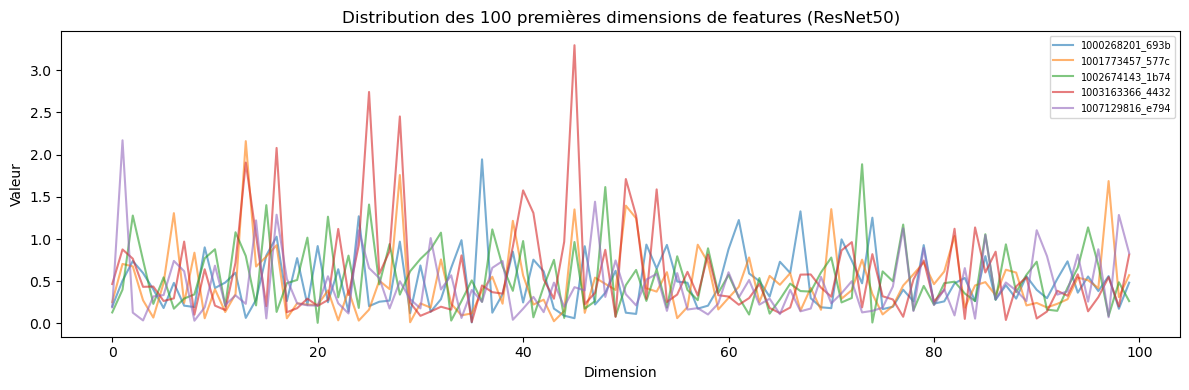


Step 1 terminé ✓ — Features prêtes pour Step 2 (RNN) et Step 3 (Fusion)


In [10]:
# Distribution des features sur quelques images
sample_keys = list(loaded.keys())[:5]
plt.figure(figsize=(12, 4))
for k in sample_keys:
    plt.plot(loaded[k][:100], alpha=0.6, label=k[:15])
plt.title('Distribution des 100 premières dimensions de features (ResNet50)')
plt.xlabel('Dimension')
plt.ylabel('Valeur')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../results/figures/features_distribution.png', dpi=150)
plt.show()

print('\nStep 1 terminé ✓ — Features prêtes pour Step 2 (RNN) et Step 3 (Fusion)')

---
# Step 2 — Text Processing with Embeddings and RNN

> 🔲 **À venir** — Tokenisation des captions, embeddings (GloVe / Word2Vec / BERT), modèle LSTM/GRU.

---
# Step 3 — Multi-Modal Fusion

> 🔲 **À venir** — Concaténation des features CNN + RNN, couches fully connected, softmax.

---
# Step 4 — Model Tuning & Optimization

> 🔲 **À venir** — Hyperparameter search, regularisation (dropout), cross-validation, évaluation finale.